#### Bag-of-Words representation

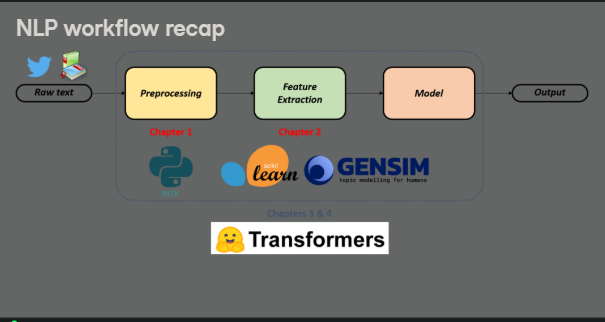

### Bag-of-Words (BoW)
- Foundational technique to represent text as numbers
- Represent text by counting how often each words appears
- Throws words in a bag and counts them
- Ignore grammar and order

BoW example
- Build a vocabulary of all unique words
- Count how many times each word from the vocabulary appears

BoW with code

In [3]:
from nltk import word_tokenize
import string
reviews = ["I love the movie. It was amazing!",
"The movies was okeay.",
"I hated the movie. It was boring."]

def preprocess(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in string.punctuation]
    return " ".join(tokens)

cleaned_reviews = [preprocess(review) for review in reviews]
print(cleaned_reviews)

['i love the movie it was amazing', 'the movies was okeay', 'i hated the movie it was boring']


In [4]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
vectorizer.fit(cleaned_reviews)
print(vectorizer.get_feature_names_out())

['amazing' 'boring' 'hated' 'it' 'love' 'movie' 'movies' 'okeay' 'the'
 'was']


In [5]:
X = vectorizer.transform(cleaned_reviews)
# OR
X = vectorizer.fit_transform(cleaned_reviews)

print(X)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 16 stored elements and shape (3, 10)>
  Coords	Values
  (0, 4)	1
  (0, 8)	1
  (0, 5)	1
  (0, 3)	1
  (0, 9)	1
  (0, 0)	1
  (1, 8)	1
  (1, 9)	1
  (1, 6)	1
  (1, 7)	1
  (2, 8)	1
  (2, 5)	1
  (2, 3)	1
  (2, 9)	1
  (2, 2)	1
  (2, 1)	1


In [6]:
print(X.toarray())

[[1 0 0 1 1 1 0 0 1 1]
 [0 0 0 0 0 0 1 1 1 1]
 [0 1 1 1 0 1 0 0 1 1]]


### Word Frequencies

In [7]:
import numpy as np
word_counts = np.sum(X.toarray(), axis=0)
words = vectorizer.get_feature_names_out()

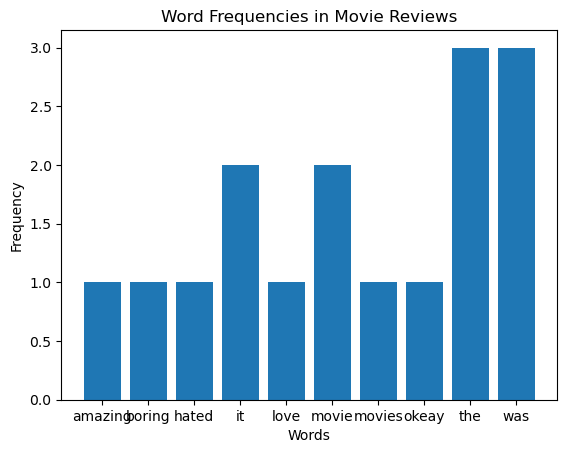

In [8]:
import matplotlib.pyplot as plt

plt.bar(words, word_counts)
plt.title("Word Frequencies in Movie Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [9]:
reviews = [
    "The product is fantastic! It works like a charm.",
    "I hated the product. It broke after one use.",
    "Product was okay, not the best, but fine overall."
]
# Preprocess the reviews
cleaned_reviews = [preprocess(review) for review in reviews]

vectorizer = CountVectorizer()
# Fit the vectorizer
vectorizer.fit(cleaned_reviews)
# Print the vocabulary 
print(vectorizer.get_feature_names_out())

['after' 'best' 'broke' 'but' 'charm' 'fantastic' 'fine' 'hated' 'is' 'it'
 'like' 'not' 'okay' 'one' 'overall' 'product' 'the' 'use' 'was' 'works']


### Transforming text to numbers with BoW


In [10]:
# Transform the reviews
bow_matrix = vectorizer.transform(cleaned_reviews)

# Print the BoW representation
print(bow_matrix.toarray())

[[0 0 0 0 1 1 0 0 1 1 1 0 0 0 0 1 1 0 0 1]
 [1 0 1 0 0 0 0 1 0 1 0 0 0 1 0 1 1 1 0 0]
 [0 1 0 1 0 0 1 0 0 0 0 1 1 0 1 1 1 0 1 0]]


### Frequency analysis of product reviews

In [11]:
def preprocess(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in string.punctuation]
    return " ".join(tokens)
  
cleaned_reviews = [preprocess(review) for review in product_reviews]
X = vectorizer.fit_transform(cleaned_reviews)

# Get word counts
word_counts = np.sum(X.toarray(), axis=0)
# Get words
words = vectorizer.get_feature_names_out()

top_words_with_stopwords, top_counts_with_stopwords = get_top_ten(words, word_counts)
print(top_words_with_stopwords, top_counts_with_stopwords)

NameError: name 'product_reviews' is not defined